In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("https://data.cityofnewyork.us/resource/jb7j-dtam.csv")

In [4]:
df

,year,leading_cause,sex,race_ethnicity,deaths,death_rate,age_adjusted_death_rate
0,2021,All Other Causes,Male,Hispanic,1695,141.8,162.7
1,2021,Malignant Neoplasms (Cancer: C00-C97),Female,Non-Hispanic White,2427,177.6,112.8
2,2021,Influenza (Flu) and Pneumonia (J09-J18),Male,Non-Hispanic Black,196,23.2,22.5
3,2021,Covid-19,Female,Hispanic,966,76.1,66.8
4,2021,"Accidents Except Drug Poisoning (V01-X39, X43,...",Male,Non-Hispanic White,266,20.1,16.6
...,...,...,...,...,...,...,...
995,2015,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Other Race/ Ethnicity,22,NaN,NaN
996,2015,Essential Hypertension and Renal Diseases (I10...,Female,Not Stated/Unknown,11,NaN,NaN
997,2015,Malignant Neoplasms (Cancer: C00-C97),Female,Other Race/ Ethnicity,12,NaN,NaN
998,2015,Essential Hypertension and Renal Diseases (I10...,Female,Other Race/ Ethnicity,4,NaN,NaN


In [5]:
df["leading_cause"] = df["leading_cause"].astype(str).str.strip()
df["sex"] = df["sex"].astype(str).str.strip()
df["race_ethnicity"] = df["race_ethnicity"].astype(str).str.strip()

numeric_cols = ["deaths", "death_rate", "age_adjusted_death_rate"]
for col in numeric_cols:
  # Coerce invalid text entries (e.g., '.', missing data) into NaN
  df[col] = pd.to_numeric(df[col], errors="coerce")

df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [6]:
df_clean = df.dropna(subset=["deaths"]).copy()
df_clean = df_clean[
    ~df_clean["leading_cause"].str.contains(
        "All Other Causes", case=False, na=False
    )
]

In [7]:
top_causes = (
    df_clean.groupby("leading_cause")["deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

/tmp/ipykernel_742/993815953.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


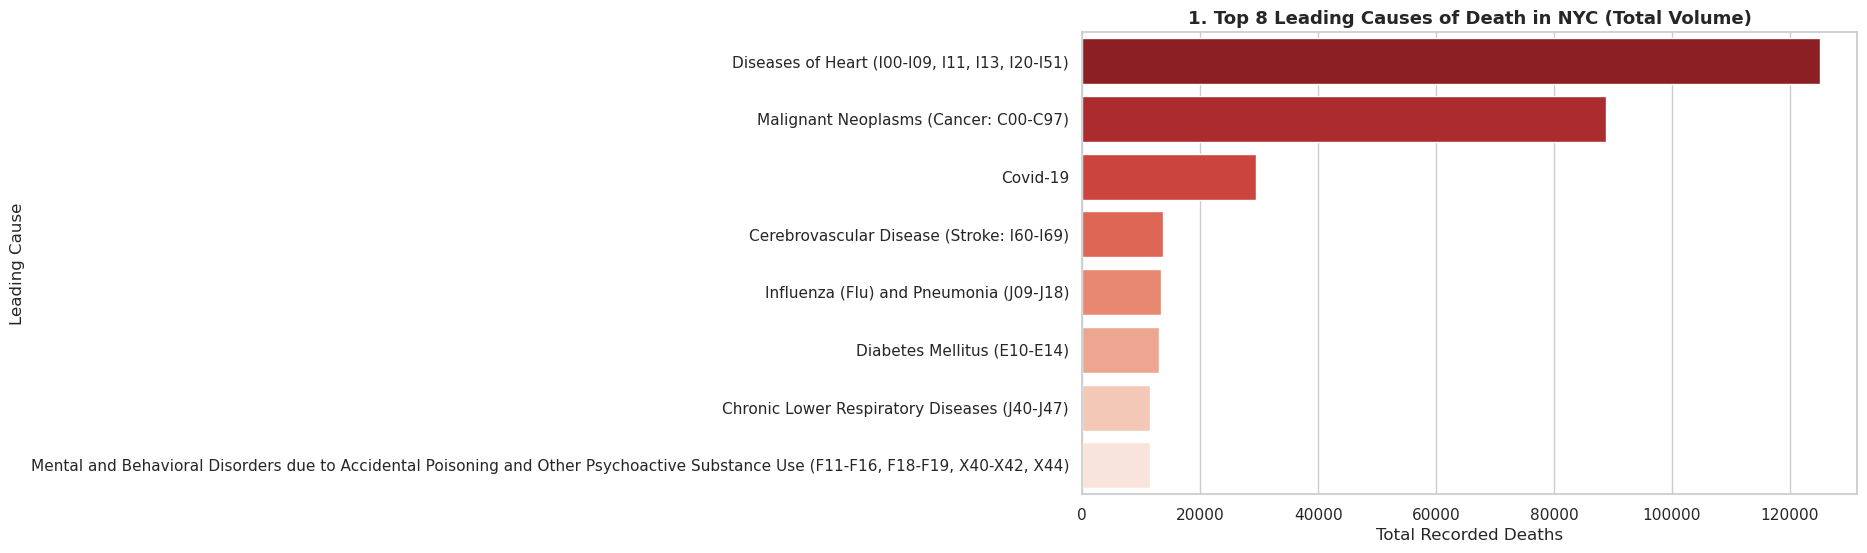

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_causes.values, y=top_causes.index, palette="Reds_r", hue=top_causes.index, legend=False
)
plt.title("1. Top 8 Leading Causes of Death in NYC (Total Volume)", fontsize=13, fontweight="bold")
plt.xlabel("Total Recorded Deaths")
plt.ylabel("Leading Cause")
plt.tight_layout()
plt.show()

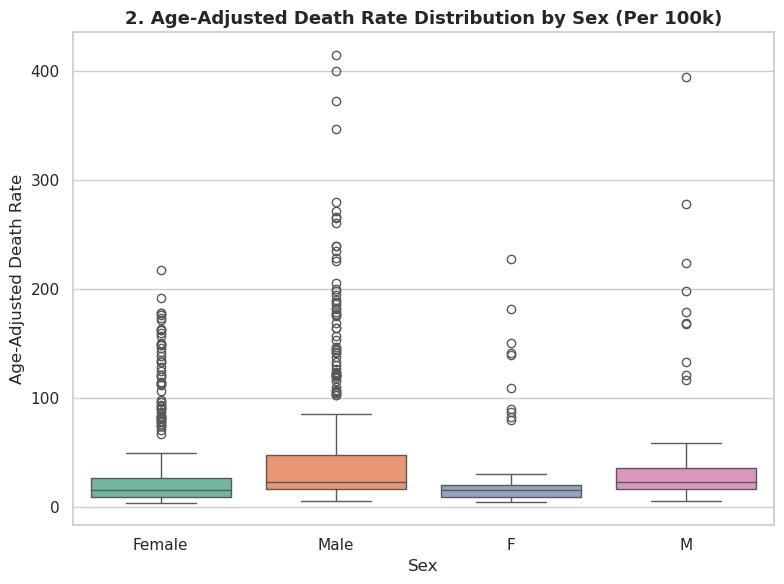

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_clean,
    x="sex",
    y="age_adjusted_death_rate",
    palette="Set2",
    hue="sex",
    legend=False
)
plt.title("2. Age-Adjusted Death Rate Distribution by Sex (Per 100k)", fontsize=13, fontweight="bold")
plt.xlabel("Sex")
plt.ylabel("Age-Adjusted Death Rate")
plt.tight_layout()
plt.show()

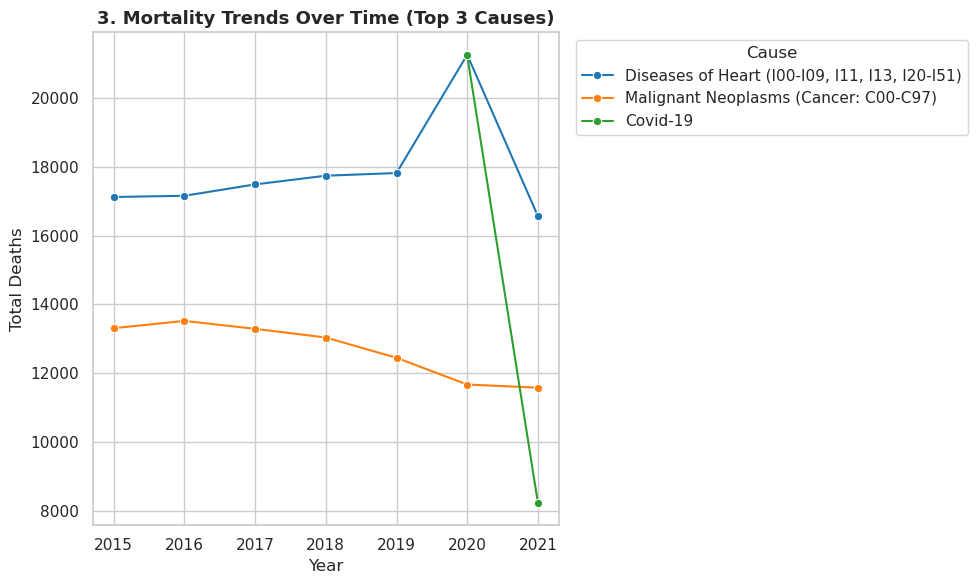

In [10]:
top_3_causes = top_causes.head(3).index.tolist()
df_top3 = df_clean[df_clean["leading_cause"].isin(top_3_causes)]
yearly_trends = df_top3.groupby(["year", "leading_cause"])["deaths"].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=yearly_trends,
    x="year",
    y="deaths",
    hue="leading_cause",
    marker="o",
    palette="tab10"
)
plt.title("3. Mortality Trends Over Time (Top 3 Causes)", fontsize=13, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.legend(title="Cause", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

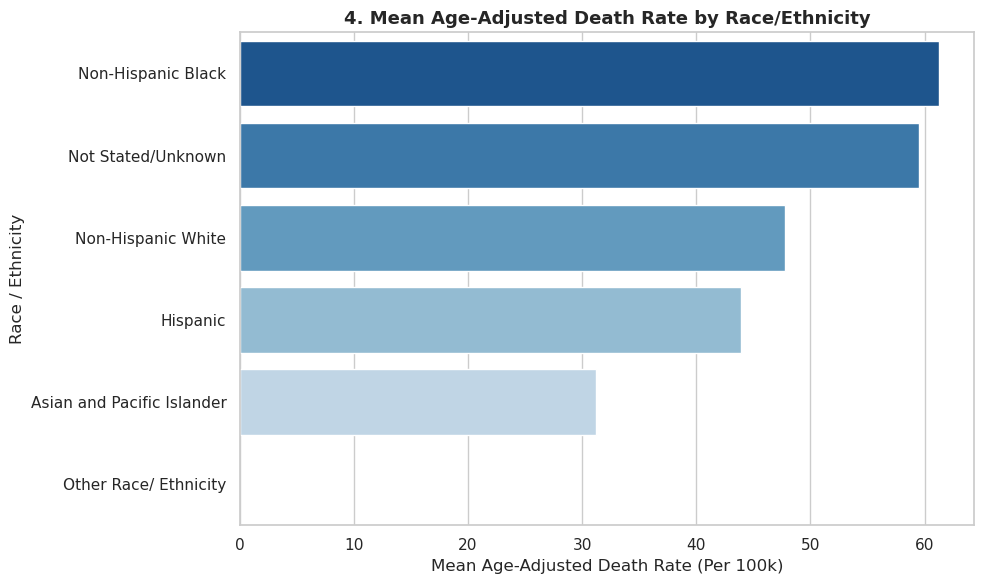

In [11]:
ethnicity_rates = (
    df_clean.groupby("race_ethnicity")["age_adjusted_death_rate"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=ethnicity_rates.values,
    y=ethnicity_rates.index,
    palette="Blues_r",
    hue=ethnicity_rates.index,
    legend=False
)
plt.title("4. Mean Age-Adjusted Death Rate by Race/Ethnicity", fontsize=13, fontweight="bold")
plt.xlabel("Mean Age-Adjusted Death Rate (Per 100k)")
plt.ylabel("Race / Ethnicity")
plt.tight_layout()
plt.show()